# Chapter 6 — IoT Gateways and Edge Processing: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

This notebook accompanies Chapter 6. Because this is an introductory architecture chapter, the four exercises focus on one engineering idea at a time and avoid vendor-specific tools. They use transparent synthetic assumptions so that the reader can change a parameter and see how gateway design affects correctness, latency, bandwidth, and availability.

**Exercises**
1. Version-aware protocol translation and canonical telemetry
2. Gateway compute sizing under mixed edge workloads
3. A simple hybrid edge–cloud AI policy
4. Redundant gateways and common-cause failure

No cloud account or external dataset is required.

---
## Setup

The notebook uses NumPy, pandas, Matplotlib, and scikit-learn. All random generators use fixed seeds for reproducibility. The numerical values are pedagogical assumptions, not measurements of a commercial gateway or cloud service.

In [1]:
import math
import pickle
import heapq
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

OUTPUT_DIR = Path('.')
np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.max_columns', 20)
print('Environment ready.')

Environment ready.


---
## Exercise 6.1 — Version-Aware Protocol Translation and Canonical Telemetry

### Background
A gateway often sits between devices that represent the *same* physical quantity in different units, scales, payload layouts, and schema versions. Treating protocol translation as simple byte forwarding is dangerous: a firmware update can change the meaning of a field while the payload still looks syntactically valid.

This exercise generates three device families measuring the same temperature and humidity process:

- **A-register** — integer register values in tenths of °C and tenths of %RH;
- **B-json** — floating-point °C and humidity as a fraction from 0 to 1;
- **C-binary** — firmware 1.x reports tenths of °F, while firmware 2.x reuses the same integer field for tenths of °C.

The gateway maps every source to a canonical record that preserves the device identifier, timestamp, firmware version, engineering units, quality state, and schema version. The firmware change in Family C is deliberately chosen so that a naive parser produces a wrong but still physically plausible temperature, making the error genuinely *silent* under a simple range check.

In [2]:
# ── Exercise 6.1: heterogeneous raw records ─────────────────────────────
rng = np.random.default_rng(42)
N = 60
minute = np.arange(N)
true_temp = 22 + 1.8 * np.sin(2 * np.pi * minute / 60) + 0.2 * np.sin(2 * np.pi * minute / 15)
true_hum = 52 + 6 * np.cos(2 * np.pi * minute / 60)

records = []

# Family A: legacy register map — 0.1 °C and 0.1 %RH.
for i in range(N):
    records.append({
        'minute': i, 'device': 'A-register', 'fw': '1.0',
        'raw_temp': int(round((true_temp[i] + rng.normal(0, 0.12)) * 10)),
        'raw_hum': int(round((true_hum[i] + rng.normal(0, 0.5)) * 10)),
        'quality': True
    })

# Family B: JSON-like payload — °C and RH fraction.
for i in range(N):
    records.append({
        'minute': i, 'device': 'B-json', 'fw': '1.2',
        'raw_temp': float(true_temp[i] + rng.normal(0, 0.15)),
        'raw_hum': float((true_hum[i] + rng.normal(0, 0.7)) / 100),
        'quality': i not in (17, 41)   # two source-side bad-quality flags
    })

# Family C: the field stays integer, but its unit changes at t=30.
for i in range(N):
    fw = '2.0' if i >= 30 else '1.0'
    measured_c = true_temp[i] + rng.normal(0, 0.10)
    if fw == '1.0':
        measured_f = measured_c * 9 / 5 + 32
        raw_temp = int(round(measured_f * 10))      # 0.1 °F
    else:
        raw_temp = int(round(measured_c * 10))      # 0.1 °C

    records.append({
        'minute': i, 'device': 'C-binary', 'fw': fw,
        'raw_temp': raw_temp,
        'raw_hum': int(np.clip(round(true_hum[i] + rng.normal(0, 0.6)), 0, 100)),
        'quality': True
    })

raw = pd.DataFrame(records)
raw.head()

,minute,device,fw,raw_temp,raw_hum,quality
0,0,A-register,1.0,220.0,575.0,True
1,1,A-register,1.0,224.0,584.0,True
2,2,A-register,1.0,223.0,572.0,True
3,3,A-register,1.0,228.0,575.0,True
4,4,A-register,1.0,229.0,571.0,True


In [3]:
def canonicalize(row, version_aware=True):
    """Translate one heterogeneous record to a small canonical telemetry record."""
    if row.device == 'A-register':
        temp_c = row.raw_temp / 10.0
        hum_pct = row.raw_hum / 10.0
    elif row.device == 'B-json':
        temp_c = float(row.raw_temp)
        hum_pct = float(row.raw_hum) * 100.0
    elif row.device == 'C-binary':
        if version_aware:
            # Version-aware adapter: known firmware families are handled explicitly.
            # An unrecognised version is rejected rather than guessed, so a future
            # firmware change cannot silently reuse the wrong unit interpretation.
            if row.fw.startswith('1.'):
                temp_f = row.raw_temp / 10.0
                temp_c = (temp_f - 32.0) * 5.0 / 9.0
            elif row.fw == '2.0':
                temp_c = row.raw_temp / 10.0
            else:
                raise ValueError(f"Unsupported firmware version for C-binary: {row.fw!r}")
        else:
            # Naive adapter: always assumes the original firmware-1.x encoding.
            temp_f = row.raw_temp / 10.0
            temp_c = (temp_f - 32.0) * 5.0 / 9.0
        hum_pct = float(row.raw_hum)
    else:
        raise ValueError('Unknown device family')

    source_quality = bool(row.quality)
    validation_ok = (-40 <= temp_c <= 85) and (0 <= hum_pct <= 100)
    return {
        'device_id': row.device,
        'event_time_min': int(row.minute),
        'firmware': row.fw,
        'temperature': temp_c,
        'temperature_unit': 'degC',
        'humidity': hum_pct,
        'humidity_unit': '%',
        'source_quality': source_quality,
        'validation_ok': validation_ok,
        'schema_version': 'gateway-telemetry-v1'
    }

naive = pd.DataFrame(raw.apply(lambda r: canonicalize(r, version_aware=False), axis=1).tolist())
aware = pd.DataFrame(raw.apply(lambda r: canonicalize(r, version_aware=True), axis=1).tolist())

raw['temp_naive'] = naive['temperature']
raw['temp_canonical'] = aware['temperature']
raw['flagged_naive'] = ~(naive['source_quality'] & naive['validation_ok'])
raw['flagged_canonical'] = ~(aware['source_quality'] & aware['validation_ok'])
raw['true_temp'] = raw['minute'].map(dict(zip(minute, true_temp)))

summary_61 = []
for dev, g in raw.groupby('device'):
    summary_61.append({
        'device': dev,
        'MAE naive (°C)': np.mean(np.abs(g.temp_naive - g.true_temp)),
        'MAE version-aware (°C)': np.mean(np.abs(g.temp_canonical - g.true_temp)),
        'flags naive / aware': f"{int(g.flagged_naive.sum())} / {int(g.flagged_canonical.sum())}"
    })
summary_61 = pd.DataFrame(summary_61)

example = raw[(raw.device == 'C-binary') & (raw.fw == '2.0')].iloc[0]
print(f"Firmware 2.0 example: raw={example.raw_temp:.0f} -> naive={example.temp_naive:.1f} °C, "
      f"version-aware={example.temp_canonical:.1f} °C")

# Fail-closed demonstration: an unrecognised firmware version is rejected outright
# rather than silently reinterpreted with the wrong unit.
import types
bad_row = types.SimpleNamespace(device='C-binary', minute=0, fw='3.0', raw_temp=250,
                                 raw_hum=50, quality=True)
try:
    canonicalize(bad_row, version_aware=True)
except ValueError as exc:
    print(f"Version-aware adapter on unknown firmware '3.0': rejected -> {exc}")

summary_61.round(3)

Firmware 2.0 example: raw=222 -> naive=-5.4 °C, version-aware=22.2 °C
Version-aware adapter on unknown firmware '3.0': rejected -> Unsupported firmware version for C-binary: '3.0'


,device,MAE naive (°C),MAE version-aware (°C),flags naive / aware
0,A-register,0.086,0.086,0 / 0
1,B-json,0.122,0.122,2 / 2
2,C-binary,13.554,0.090,0 / 0


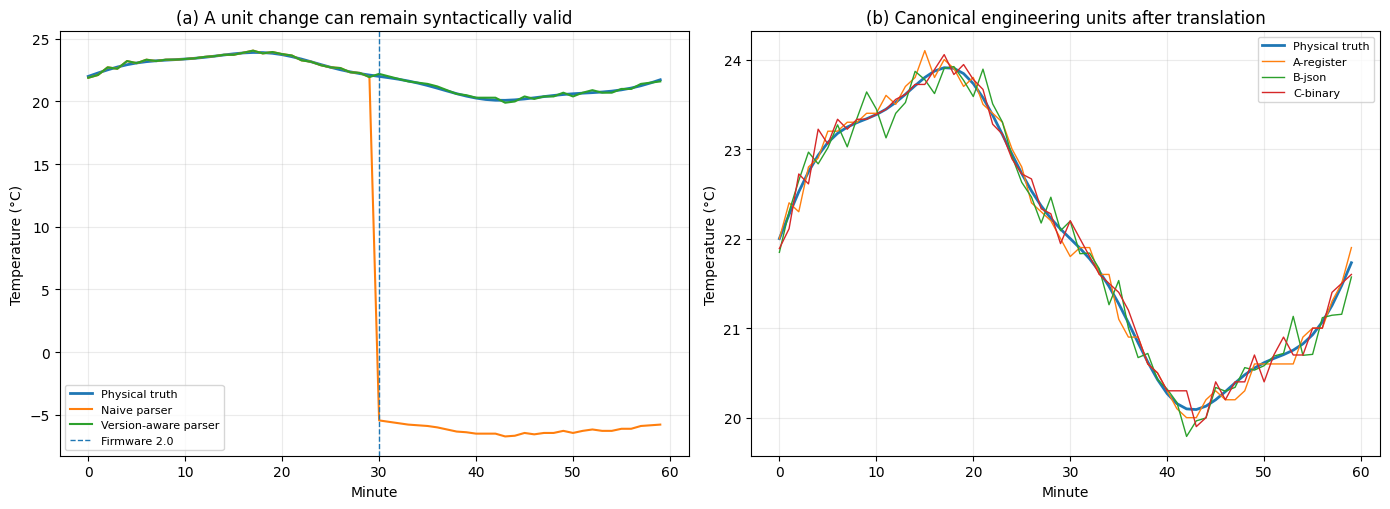

    device  MAE naive (°C)  MAE version-aware (°C) flags naive / aware
A-register           0.086                   0.086               0 / 0
    B-json           0.122                   0.122               2 / 2
  C-binary          13.554                   0.090               0 / 0


In [4]:
# ── Figure 6.1 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

c = raw[raw.device == 'C-binary']
axes[0].plot(c.minute, c.true_temp, label='Physical truth', linewidth=2)
axes[0].plot(c.minute, c.temp_naive, label='Naive parser')
axes[0].plot(c.minute, c.temp_canonical, label='Version-aware parser')
axes[0].axvline(30, linestyle='--', linewidth=1, label='Firmware 2.0')
axes[0].set_title('(a) A unit change can remain syntactically valid')
axes[0].set_xlabel('Minute')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(minute, true_temp, linewidth=2, label='Physical truth')
for dev, g in raw.groupby('device'):
    axes[1].plot(g.minute, g.temp_canonical, linewidth=1, label=dev)
axes[1].set_title('(b) Canonical engineering units after translation')
axes[1].set_xlabel('Minute')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_6_1_normalization.png', dpi=180, bbox_inches='tight')
plt.show()

print(summary_61.round(3).to_string(index=False))

### Analysis
The first two device families remain close to the physical process because their contracts do not change. Family C is different. After firmware 2.0, a raw value such as `222` means **22.2 °C**. A parser that still assumes tenths of °F reads the same integer as **22.2 °F = −5.4 °C**. That value is wrong by about 27 °C, yet it still lies inside the deliberately broad −40 to 85 °C plausibility range, so a simple range check does not detect the semantic error.

The version-aware adapter restores the error to the level of the injected sensor noise and preserves enough metadata to show how the value was interpreted. Canonicalization still does **not** calibrate the sensor; it only prevents protocol and schema heterogeneity from leaking into every downstream application.

**Challenge tasks**
- Add a fourth device family that reports Kelvin.
- Change the simple physical-range check to a tighter application-specific plausibility rule.
- Remove firmware metadata and propose one safe way to detect an unexpected schema change.

---
## Exercise 6.2 — Gateway Compute Sizing Under Mixed Edge Workloads

### Background
A gateway is not sized only by message rate. Protocol translation, validation, local rules, and Edge AI consume different amounts of CPU time. This exercise introduces one simple capacity indicator: **normalised offered load**. When the offered CPU work reaches or exceeds available core-time, the queue cannot remain stable under sustained traffic.

The model uses three synthetic task classes: routine telemetry, control/event handling, and a heavier Edge-AI stage. The simulator assigns each task to the earliest available core and measures response time and normalised offered load. It is a teaching model, not a benchmark of any named gateway. Deadline-aware scheduling is a separate concern and is treated quantitatively in Chapter 27.

In [5]:
def simulate_gateway(rate, cores, duration=45, seed=123):
    """Simple multi-server discrete-event model with heterogeneous service times."""
    rng = np.random.default_rng(seed + int(rate) * 10 + cores)
    classes = np.array(['telemetry', 'control', 'edge-AI'])
    probs = np.array([0.70, 0.20, 0.10])
    mean_ms = {'telemetry': 0.45, 'control': 0.80, 'edge-AI': 4.0}

    arrivals = []
    t = 0.0
    while t < duration:
        t += rng.exponential(1.0 / rate)
        if t >= duration:
            break
        cls = rng.choice(classes, p=probs)
        sigma = 0.35
        mu = np.log(mean_ms[cls]) - 0.5 * sigma**2
        service = rng.lognormal(mu, sigma)
        arrivals.append((t, cls, service))

    available = [0.0] * cores
    response_ms = []
    service_sum_ms = 0.0

    for arrival, cls, service_ms in arrivals:
        j = min(range(cores), key=lambda k: available[k])
        start = max(arrival, available[j])
        finish = start + service_ms / 1000.0
        available[j] = finish
        rt = (finish - arrival) * 1000.0
        response_ms.append(rt)
        service_sum_ms += service_ms

    # rho is offered CPU work divided by available core-time over the fixed horizon.
    rho = service_sum_ms / (duration * 1000 * cores)
    return {
        'rate (events/s)': rate,
        'cores': cores,
        'tasks': len(arrivals),
        'offered load rho': rho,
        'p95 latency (ms)': np.percentile(response_ms, 95),
    }

rates = [400, 800, 1200, 1600, 2000, 2400, 2800]
rows = [simulate_gateway(r, c) for c in (1, 2, 4) for r in rates]
summary_62 = pd.DataFrame(rows)
summary_62.round(3)

,rate (events/s),cores,tasks,offered load rho,p95 latency (ms)
0,400,1,18043,0.351,5.669
1,800,1,35771,0.698,11.982
2,1200,1,54101,1.048,1998.936
3,1600,1,72439,1.408,17402.995
4,2000,1,89955,1.746,31941.842
5,2400,1,107897,2.094,46779.186
6,2800,1,125849,2.446,61743.940
7,400,2,18189,0.177,3.801
8,800,2,35510,0.347,4.149
9,1200,2,53965,0.529,4.753


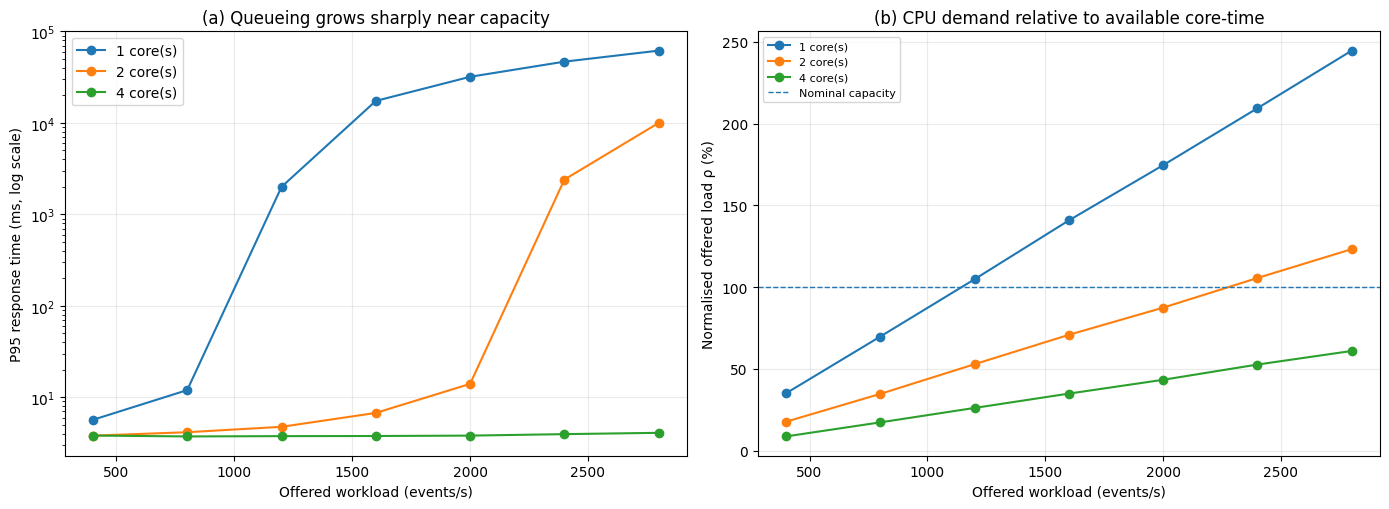

Selected operating points:
 rate (events/s)  cores  tasks  offered load rho  p95 latency (ms)
             800      1  35771             0.698            11.982
            1200      1  54101             1.048          1998.936
            2400      1 107897             2.094         46779.186
            1200      2  53965             0.529             4.753
            2000      2  90059             0.875            14.006
            2400      2 108382             1.056          2402.527
            2400      4 107288             0.527             3.953
            2800      4 125861             0.610             4.086


In [6]:
# ── Figure 6.2 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for cores, g in summary_62.groupby('cores'):
    axes[0].plot(g['rate (events/s)'], g['p95 latency (ms)'], marker='o', label=f'{cores} core(s)')
axes[0].set_yscale('log')
axes[0].set_xlabel('Offered workload (events/s)')
axes[0].set_ylabel('P95 response time (ms, log scale)')
axes[0].set_title('(a) Queueing grows sharply near capacity')
axes[0].legend()
axes[0].grid(alpha=0.25)

for cores, g in summary_62.groupby('cores'):
    axes[1].plot(g['rate (events/s)'], 100 * g['offered load rho'], marker='o', label=f'{cores} core(s)')
axes[1].axhline(100, linestyle='--', linewidth=1, label='Nominal capacity')
axes[1].set_xlabel('Offered workload (events/s)')
axes[1].set_ylabel('Normalised offered load ρ (%)')
axes[1].set_title('(b) CPU demand relative to available core-time')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_6_2_sizing.png', dpi=180, bbox_inches='tight')
plt.show()

print('Selected operating points:')
selected = summary_62[
    ((summary_62.cores == 1) & summary_62['rate (events/s)'].isin([800, 1200, 2400])) |
    ((summary_62.cores == 2) & summary_62['rate (events/s)'].isin([1200, 2000, 2400])) |
    ((summary_62.cores == 4) & summary_62['rate (events/s)'].isin([2400, 2800]))
]
print(selected.round(3).to_string(index=False))

### Analysis
The one-core configuration is responsive at 800 events/s, where the offered load is about 0.70. At 1,200 events/s, `ρ ≈ 1.05`: the offered CPU work is greater than the available core-time. The queue is therefore **unstable under sustained traffic**. The reported P95 values for `ρ ≥ 1` are finite-horizon simulation outcomes, not steady-state latency guarantees; if the same overload continued, the queue would keep growing.

The two-core system moves the saturation point upward, and four cores provide ample headroom over the tested range. The practical lesson is simple: first check whether offered work fits within capacity, then verify tail latency on the real target hardware. A measured average CPU percentage is useful, but by itself it cannot describe bursts or queueing. Deadline-aware scheduling and admission control are treated separately in Chapter 27.

**Challenge tasks**
- Increase the Edge-AI share from 10% to 20% and rerun the sweep.
- For two cores, find the highest tested rate that keeps `ρ < 0.8`.
- Explain why a design engineer should still measure P95 latency even when `ρ < 1`.

---
## Exercise 6.3 — A Simple Hybrid Edge–Cloud AI Policy

### Background
Edge AI does not require choosing “all local” or “all cloud.” A simple hybrid policy can run a compact local model first and ask a larger remote model only for uncertain cases. The engineering question is then broader than accuracy: how much latency, WAN dependence, and raw-data traffic does the policy introduce?

This exercise trains two reproducible classifiers on a synthetic dataset. A logistic-regression pipeline represents the gateway model and a random forest represents a larger remote model. The remote model is executed locally only to make the accuracy comparison reproducible. WAN latency and outages are synthetic architectural assumptions, not measurements of scikit-learn or a cloud provider.

In [7]:
# ── Train compact edge and larger cloud models ──────────────────────────
X, y = make_classification(
    n_samples=7000, n_features=12, n_informative=8, n_redundant=2,
    n_clusters_per_class=2, class_sep=1.05, flip_y=0.04,
    weights=[0.52, 0.48], random_state=77
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=77
)

edge_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=500, random_state=77)
)
cloud_model = RandomForestClassifier(
    n_estimators=180, max_depth=9, min_samples_leaf=2,
    n_jobs=-1, random_state=77
)
edge_model.fit(X_train, y_train)
cloud_model.fit(X_train, y_train)

edge_prob = edge_model.predict_proba(X_test)
cloud_prob = cloud_model.predict_proba(X_test)
edge_pred = np.argmax(edge_prob, axis=1)
cloud_pred = np.argmax(cloud_prob, axis=1)
edge_conf = edge_prob.max(axis=1)

print(f'Edge-model test accuracy:  {accuracy_score(y_test, edge_pred):.3%}')
print(f'Cloud-model test accuracy: {accuracy_score(y_test, cloud_pred):.3%}')
print(f'Pickled edge model:  {len(pickle.dumps(edge_model))/1024:.1f} KiB')
print(f'Pickled cloud model: {len(pickle.dumps(cloud_model))/1024:.1f} KiB')

Edge-model test accuracy:  89.286%
Cloud-model test accuracy: 92.857%
Pickled edge model:  1.4 KiB
Pickled cloud model: 4750.7 KiB


In [8]:
# ── Simulated deployment conditions ────────────────────────────────────
rng = np.random.default_rng(2026)
N_test = len(y_test)

# Architectural latency assumptions, not host timing measurements.
edge_latency = np.clip(rng.normal(11, 2, N_test), 4, None)
wan_latency = np.clip(rng.lognormal(mean=np.log(70), sigma=0.45, size=N_test), 15, 400)
cloud_compute = np.clip(rng.normal(18, 4, N_test), 5, None)
cloud_latency = wan_latency + cloud_compute

WAN_OUTAGE_PROB = 0.05
cloud_available = rng.random(N_test) > WAN_OUTAGE_PROB

RAW_BYTES = 4096       # illustrative raw feature/frame payload
EVENT_BYTES = 80       # event summary + metadata
FAILURE_DETECTION_MS = 120
THRESHOLD = 0.80

offload_attempt = edge_conf < THRESHOLD
use_cloud = offload_attempt & cloud_available
failed_offload = offload_attempt & ~cloud_available

hybrid_pred = edge_pred.copy()
hybrid_pred[use_cloud] = cloud_pred[use_cloud]

hybrid_latency = edge_latency.copy()
hybrid_latency[use_cloud] = edge_latency[use_cloud] + cloud_latency[use_cloud]
hybrid_latency[failed_offload] = edge_latency[failed_offload] + FAILURE_DETECTION_MS

# Traffic accounting: every local/hybrid decision emits an 80-byte summary.
# A hybrid decision additionally offers one raw payload whenever remote help is requested.
summary_63 = pd.DataFrame([
    {
        'policy': 'Edge only',
        'decision availability (%)': 100.0,
        'accuracy conditional on delivered decision (%)': 100 * accuracy_score(y_test, edge_pred),
        'p95 decision latency (ms)': np.percentile(edge_latency, 95),
        'offered uplink bytes / sample': EVENT_BYTES,
        'offload attempts (%)': 0.0
    },
    {
        'policy': 'Cloud only',
        'decision availability (%)': 100 * cloud_available.mean(),
        'accuracy conditional on delivered decision (%)': 100 * accuracy_score(y_test[cloud_available], cloud_pred[cloud_available]),
        'p95 decision latency (ms)': np.percentile(cloud_latency[cloud_available], 95),
        'offered uplink bytes / sample': RAW_BYTES,
        'offload attempts (%)': 100.0
    },
    {
        'policy': f'Hybrid, confidence < {THRESHOLD:.2f}',
        'decision availability (%)': 100.0,
        'accuracy conditional on delivered decision (%)': 100 * accuracy_score(y_test, hybrid_pred),
        'p95 decision latency (ms)': np.percentile(hybrid_latency, 95),
        'offered uplink bytes / sample': EVENT_BYTES + offload_attempt.mean() * RAW_BYTES,
        'offload attempts (%)': 100 * offload_attempt.mean()
    }
])

print(f'WAN outage probability per decision: {WAN_OUTAGE_PROB:.0%}')
print(f'Observed cloud availability in this fixed sample: {cloud_available.mean():.2%}')
print(f'Cloud-model full-test accuracy: {accuracy_score(y_test, cloud_pred):.2%}')
print(f'Cloud-model accuracy on reachable subset: {accuracy_score(y_test[cloud_available], cloud_pred[cloud_available]):.2%}')
print(f'Hybrid remote-help attempts: {offload_attempt.mean():.2%}; successful raw uploads: {use_cloud.mean():.2%}')
summary_63.round(2)

WAN outage probability per decision: 5%
Observed cloud availability in this fixed sample: 95.43%
Cloud-model full-test accuracy: 92.86%
Cloud-model accuracy on reachable subset: 92.76%
Hybrid remote-help attempts: 26.95%; successful raw uploads: 25.81%


,policy,decision availability (%),accuracy conditional on delivered decision (%),p95 decision latency (ms),offered uplink bytes / sample,offload attempts (%)
0,Edge only,100.00,89.29,14.17,80.00,0.00
1,Cloud only,95.43,92.76,163.91,4096.00,100.00
2,"Hybrid, confidence < 0.80",100.00,92.38,133.07,1183.97,26.95


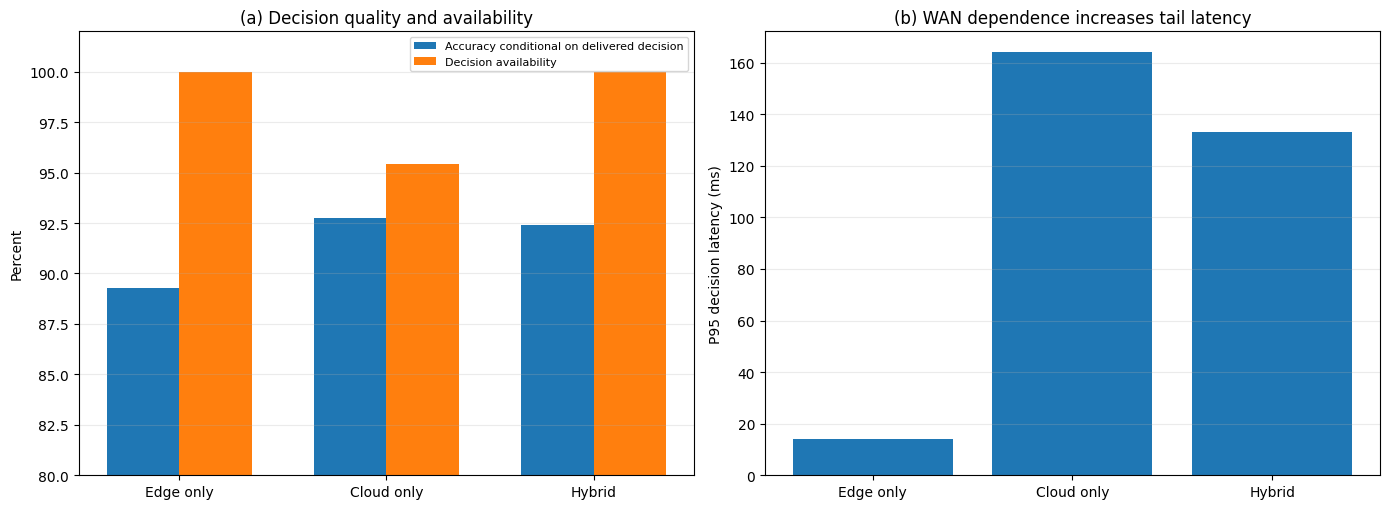

                   policy  decision availability (%)  accuracy conditional on delivered decision (%)  p95 decision latency (ms)  offered uplink bytes / sample  offload attempts (%)
                Edge only                     100.00                                           89.29                      14.17                          80.00                  0.00
               Cloud only                      95.43                                           92.76                     163.91                        4096.00                100.00
Hybrid, confidence < 0.80                     100.00                                           92.38                     133.07                        1183.97                 26.95


In [9]:
# ── Figure 6.3: compare the three policies directly ────────────────────
labels = summary_63['policy'].tolist()
x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes[0].bar(x - width / 2, summary_63['accuracy conditional on delivered decision (%)'], width, label='Accuracy conditional on delivered decision')
axes[0].bar(x + width / 2, summary_63['decision availability (%)'], width, label='Decision availability')
axes[0].set_xticks(x, ['Edge only', 'Cloud only', 'Hybrid'])
axes[0].set_ylim(80, 102)
axes[0].set_ylabel('Percent')
axes[0].set_title('(a) Decision quality and availability')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(x, summary_63['p95 decision latency (ms)'])
axes[1].set_xticks(x, ['Edge only', 'Cloud only', 'Hybrid'])
axes[1].set_ylabel('P95 decision latency (ms)')
axes[1].set_title('(b) WAN dependence increases tail latency')
axes[1].grid(axis='y', alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_6_3_edge_ai.png', dpi=180, bbox_inches='tight')
plt.show()

print(summary_63.round(2).to_string(index=False))

### Analysis
The compact local model is less accurate than the larger model, but every test case receives a local decision with low assumed latency. The larger model scores **92.86% on the complete test set**. After the fixed random WAN mask is applied, the cloud-only policy delivers decisions for **95.43%** of samples, and accuracy on that reachable subset is **92.76%**. These percentages answer different questions and should not be confused.

At the default threshold, the hybrid policy requests remote help for about **26.95%** of samples; **25.81%** actually reach the cloud in this particular outage realization. It preserves a local decision for every sample and reaches 92.38% overall accuracy. For traffic budgeting, the notebook counts an 80-byte event summary for each hybrid sample plus a 4 KiB raw payload for each *attempted* offload. `FAILURE_DETECTION_MS` is only the synthetic delay used when the WAN is marked unavailable; successful remote requests use the sampled WAN-plus-cloud latency and are not subject to a 120 ms hard deadline.

The central lesson is intentionally modest: a hybrid policy can trade raw-data traffic and WAN exposure for some of the accuracy benefit of a larger remote model. Production systems require more work—confidence calibration, model monitoring, and real network measurements—but those topics are not needed to understand the architectural trade-off here.

**Challenge tasks**
- Change the confidence threshold to 0.70 and 0.90 and compare the table.
- Increase the WAN outage probability from 5% to 15%.
- Replace the 4 KiB raw payload with a 200 KiB image and compare the offered uplink traffic.

---
## Exercise 6.4 — Redundant Gateways and Common-Cause Failure

### Background
A gateway can become a single point of failure. Adding a second gateway helps only when the two units do not share every failure domain. Power, switching, backhaul, credentials, or a common software defect can still remove both paths.

The simulation uses two independent gateway health processes plus a separate **site/common-cause** process. It compares a single gateway, active–passive failover, and hot active–active redundancy. The failure rates are deliberately accelerated so that visible events occur in a two-week classroom run; they are not estimates of real industrial gateway reliability.

In [10]:
def markov_health(n, dt, mtbf_s, mttr_s, rng):
    health = np.ones(n, dtype=bool)
    for i in range(1, n):
        if health[i-1]:
            health[i] = not (rng.random() < dt/mtbf_s)
        else:
            health[i] = (rng.random() < dt/mttr_s)
    return health


def simulate_redundancy(days=14, dt=5, seed=2026,
                        gateway_mtbf_h=24, gateway_mttr_min=20,
                        common_mtbf_h=72, common_mttr_min=8,
                        failover_delay_s=10):
    # Five-second steps keep the classroom simulation fast and transparent.
    n = int(days*24*3600/dt)
    rng = np.random.default_rng(seed)
    A = markov_health(n, dt, gateway_mtbf_h*3600, gateway_mttr_min*60, rng)
    B = markov_health(n, dt, gateway_mtbf_h*3600, gateway_mttr_min*60, rng)
    site = markov_health(n, dt, common_mtbf_h*3600, common_mttr_min*60, rng)

    single = A & site
    active_active = (A | B) & site

    # Active–passive controller. No automatic failback: once switched, the healthy unit stays active.
    active_passive = np.zeros(n, dtype=bool)
    active = 0
    timer = 0
    for i in range(n):
        if not site[i]:
            active_passive[i] = False
            continue
        active_health = A[i] if active == 0 else B[i]
        standby_health = B[i] if active == 0 else A[i]
        if active_health:
            active_passive[i] = True
            timer = 0
        elif standby_health:
            timer += dt
            if timer >= failover_delay_s:
                active = 1 - active
                active_passive[i] = True
                timer = 0
            else:
                active_passive[i] = False
        else:
            active_passive[i] = False
            timer = 0

    return A, B, site, single, active_passive, active_active

A, B, site, single, ap, aa = simulate_redundancy()

def reliability_row(name, state):
    return {
        'architecture': name,
        'availability (%)': 100*state.mean(),
        'downtime (min / 14 d)': (~state).sum()*5/60,
    }

summary_64 = pd.DataFrame([
    reliability_row('Single gateway', single),
    reliability_row('Active-passive', ap),
    reliability_row('Active-active hot', aa),
])
summary_64.round(3)

,architecture,availability (%),downtime (min / 14 d)
0,Single gateway,98.631,276.000
1,Active-passive,99.688,62.833
2,Active-active hot,99.694,61.750


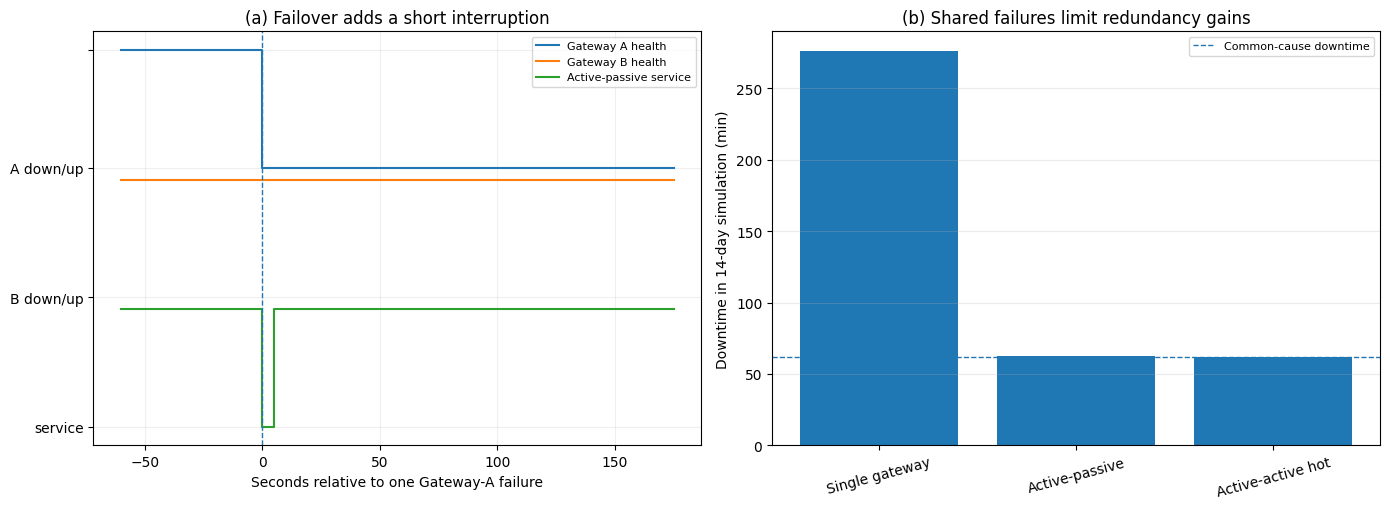

     architecture  availability (%)  downtime (min / 14 d)
   Single gateway            98.631                276.000
   Active-passive            99.688                 62.833
Active-active hot            99.694                 61.750
Common-cause/site downtime alone: 61.8 min


In [11]:
# ── Figure 6.4 ─────────────────────────────────────────────────────────
# Find an individual gateway failure outside a site outage for the timeline panel.
fail_idx = np.where(A[:-1] & ~A[1:] & site[1:])[0]
center = int(fail_idx[0] + 1) if len(fail_idx) else 10000
lo = max(0, center - 12)
hi = min(len(A), center + 36)
t_rel = (np.arange(lo, hi) - center) * 5

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes[0].step(t_rel, A[lo:hi].astype(int)+2.2, where='post', label='Gateway A health')
axes[0].step(t_rel, B[lo:hi].astype(int)+1.1, where='post', label='Gateway B health')
axes[0].step(t_rel, ap[lo:hi].astype(int), where='post', label='Active-passive service')
axes[0].axvline(0, linestyle='--', linewidth=1)
axes[0].set_yticks([0, 1.1, 2.2, 3.2])
axes[0].set_yticklabels(['service', 'B down/up', 'A down/up', ''])
axes[0].set_xlabel('Seconds relative to one Gateway-A failure')
axes[0].set_title('(a) Failover adds a short interruption')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.20)

axes[1].bar(summary_64.architecture, summary_64['downtime (min / 14 d)'])
axes[1].axhline((~site).sum()*5/60, linestyle='--', linewidth=1, label='Common-cause downtime')
axes[1].set_ylabel('Downtime in 14-day simulation (min)')
axes[1].set_title('(b) Shared failures limit redundancy gains')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_6_4_failover.png', dpi=180, bbox_inches='tight')
plt.show()

print(summary_64.round(3).to_string(index=False))
print(f'Common-cause/site downtime alone: {(~site).sum()*5/60:.1f} min')

### Analysis
Redundancy sharply reduces downtime caused by one gateway’s independent failures. Active–passive is slightly worse than hot active–active in this model because each primary failure includes a short failover interval.

The more important result is the common-cause line: both redundant architectures retain almost all site-level downtime. A second box in the same rack does not protect against the same lost power feed, upstream switch, or shared configuration mistake. The short MTBF values in this simulation are therefore best read as an **accelerated classroom failure model** chosen to create enough events for comparison, not as realistic field-reliability figures.

**Challenge tasks**
- Set common-cause failures to zero and rerun the table.
- Increase failover delay from 8 s to 60 s.
- List three real shared dependencies that could defeat two otherwise healthy gateways.

---
## Practice Section Summary

The four exercises are deliberately introductory. Exercise 6.1 shows why a gateway must understand schema versions, not only bytes. Exercise 6.2 introduces the difference between offered work and available compute capacity. Exercise 6.3 compares three simple Edge-AI placement policies without turning the chapter into a machine-learning tutorial. Exercise 6.4 shows why redundancy must be analysed by failure domain. Together they make the architecture measurable while leaving more advanced fleet management, signal processing, networking, and embedded optimisation to later chapters.